<a href="https://colab.research.google.com/github/hgkim-gnbeng/tunnel_fire_dynamics_book/blob/book_example/%EC%98%88%EC%A0%9C_6_4_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

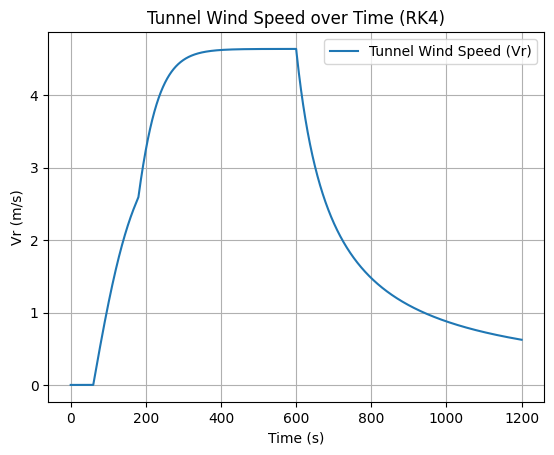

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# 상수 정의
rho = 1.225  # 공기 밀도 (kg/m^3)
zeta_e = 0.5
lambda_ = 0.025
Ar = 75         # 터널 단면적 (m²)
Lr = 1000       # 터널 길이 (m)
dh = 8.0        # 유압 직경 (m)
K = 1 + zeta_e + lambda_ * Lr / dh
M = rho * Lr  # 단면적당 등가질량 (공기)

# 제트팬 압력 생성 함수
def dP_jetfan(t, Vr):
    dj = 1.250
    Aj = np.pi / 4 * dj**2
    Vj = 30.0
    eta = 1.0
    JF_ea1 = 2
    JF_ea2 = 2 + 2
    if 60 <= t < 180:
        return (eta * rho * (Aj / Ar) * (Vj**2) * (1 - Vr / Vj) * JF_ea1 )
    elif 180 <= t <= 600 :
        return (eta * rho * (Aj / Ar) * (Vj**2) * (1 - Vr / Vj) * JF_ea2 )
    else:
        return 0.0

# 터널 압력 손실 함수
def dP_res(Vr):
    return (K * 0.5 * rho * Vr**2 )

# 풍속 변화율 (미분방정식)
def dVr_dt(Vr, t):
    return (dP_jetfan(t, Vr) - dP_res(Vr)) / M

# Runge-Kutta 4차 해법
def rk4_solver(Vr0, t0, tf, dt):
    t_values = np.arange(t0, tf + dt, dt)
    Vr_values = []
    Vr = Vr0
    for t in t_values:
        Vr_values.append(Vr)
        k1 = dVr_dt(Vr, t)
        k2 = dVr_dt(Vr + 0.5 * dt * k1, t + 0.5 * dt)
        k3 = dVr_dt(Vr + 0.5 * dt * k2, t + 0.5 * dt)
        k4 = dVr_dt(Vr + dt * k3, t + dt)
        Vr += (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return t_values, Vr_values

# 초기 조건 및 실행
Vr0 = 0.0
t0 = 0.0
tf = 1200.0
dt = 0.1
t, Vr = rk4_solver(Vr0, t0, tf, dt)

# 그래프 출력
plt.plot(t, Vr, label="Tunnel Wind Speed (Vr)")
plt.xlabel('Time (s)')
plt.ylabel('Vr (m/s)')
plt.title('Tunnel Wind Speed over Time (RK4)')
plt.grid(True)
plt.legend()
plt.show()